# Chapter 5 — Probabilistic Modelling

This notebook accompanies **Chapter 5** of *Inference in Statistical Modelling and Machine Learning*.

---

### Key ideas

- A **probabilistic model** specifies not just a prediction $g(x;\boldsymbol{\beta})$ but a full probability distribution for $Y$ given $X$.
- For Gaussian noise, $Y = g(x;\boldsymbol{\beta}) + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,\sigma^2)$, the **log-likelihood** is exactly a rescaled negative residual sum of squares.
- **Maximum likelihood estimation (MLE)** of the coefficients $\boldsymbol{\beta}$ is therefore identical to **least squares** — the two criteria look different but optimise the same thing.
- The log-likelihood **increases monotonically** with model complexity on training data — it cannot be used for model selection without a penalty.
- **Leave-one-out cross-validation (LOO-CV)** exposes the bias–variance trade-off and picks the correct complexity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

---
## 1 · A toy regression dataset

We generate $n = 40$ observations from
$$
  g(x) = 3 + 2x - \tfrac{1}{2}x^2, \qquad x \in [0, 5], \qquad \varepsilon \sim \mathcal{N}(0,\, 0.4^2).
$$
The input points $x_1,\ldots,x_{40}$ are drawn uniformly on $[0,5]$; the responses are $y_k = g(x_k) + \varepsilon_k$.

Because the model is Gaussian, the conditional distribution of $Y$ given $x$ is
$$
  Y \mid x \;\sim\; \mathcal{N}\!\left(g(x),\, \sigma^2\right).
$$
The figure below shows the data together with **probability tubes** — shaded bands at $\pm 1\sigma$ and $\pm 2\sigma$ around the true curve.

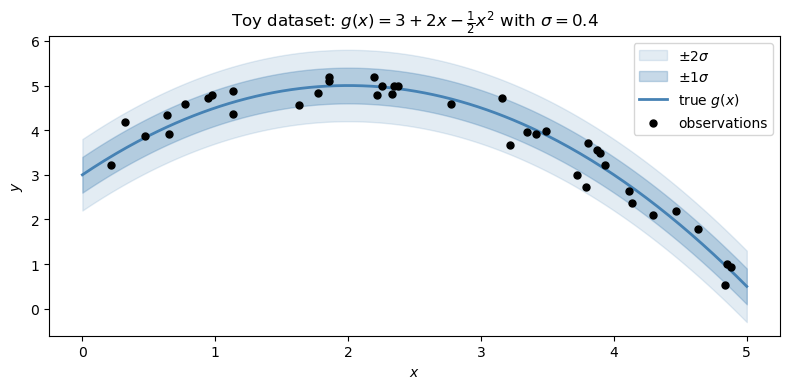

In [2]:
# ── true model parameters ──────────────────────────────────────────────────
TRUE_BETA = np.array([3.0, 2.0, -0.5])   # intercept, linear, quadratic
TRUE_SIGMA = 0.4
N = 40

def g_true(x):
    return TRUE_BETA[0] + TRUE_BETA[1]*x + TRUE_BETA[2]*x**2

# ── generate data ──────────────────────────────────────────────────────────
x_data = rng.uniform(0, 5, size=N)
y_data = g_true(x_data) + rng.normal(0, TRUE_SIGMA, size=N)

# ── plot ───────────────────────────────────────────────────────────────────
x_fine = np.linspace(0, 5, 300)
mu_fine = g_true(x_fine)

fig, ax = plt.subplots(figsize=(8, 4))

ax.fill_between(x_fine, mu_fine - 2*TRUE_SIGMA, mu_fine + 2*TRUE_SIGMA,
                alpha=0.15, color='steelblue', label=r'$\pm 2\sigma$')
ax.fill_between(x_fine, mu_fine - TRUE_SIGMA, mu_fine + TRUE_SIGMA,
                alpha=0.30, color='steelblue', label=r'$\pm 1\sigma$')
ax.plot(x_fine, mu_fine, color='steelblue', linewidth=2, label='true $g(x)$')
ax.scatter(x_data, y_data, color='black', s=25, zorder=4, label='observations')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Toy dataset: $g(x) = 3 + 2x - \\frac{1}{2}x^2$ with $\\sigma = 0.4$')
ax.legend()
plt.tight_layout()
plt.show()

Roughly 68 % of points fall inside the $\pm 1\sigma$ band and 95 % inside the $\pm 2\sigma$ band — consistent with Gaussian noise.

---
## 2 · Log-likelihood and maximum likelihood estimation

### The log-likelihood for Gaussian noise

Under the model $Y_k \mid x_k \sim \mathcal{N}(g(x_k;\boldsymbol{\beta}),\,\sigma^2)$, the log-likelihood of the parameters $(\boldsymbol{\beta}, \sigma)$ given the data is
$$
  \ell(\boldsymbol{\beta},\sigma) 
  = -\frac{1}{2\sigma^2}\sum_{k=1}^n \bigl(y_k - g(x_k;\boldsymbol{\beta})\bigr)^2
    - n\log(\sqrt{2\pi}\,\sigma).
$$

### MLE = least squares

For **fixed** $\sigma$, maximising $\ell$ over $\boldsymbol{\beta}$ is equivalent to minimising the residual sum of squares
$$
  \mathrm{RSS}(\boldsymbol{\beta}) = \sum_{k=1}^n \bigl(y_k - g(x_k;\boldsymbol{\beta})\bigr)^2.
$$
The MLE $\hat{\boldsymbol{\beta}}$ is therefore identical to the ordinary least-squares estimate — the two criteria look different but optimise the same objective.

Substituting $\hat{\boldsymbol{\beta}}$ back and differentiating with respect to $\sigma$ gives the MLE for the noise standard deviation:
$$
  \hat\sigma^2 = \frac{\mathrm{RSS}(\hat{\boldsymbol{\beta}})}{n}.
$$

> **Book link — §5.2.** The derivation above is worked through in the text; the key message is that the Gaussian noise assumption turns a geometric (least-squares) recipe into a probabilistic (maximum-likelihood) one, and the two coincide.

### Three fits compared

We fit three polynomial models and compare their log-likelihoods.
The **bad linear** fit uses a hand-picked (wrong) slope to illustrate a low-likelihood fit; the **ML linear** and **ML quadratic** fits are found by least squares.

In [ ]:
def poly_design(x, degree):
    """Matrix of polynomial features [1, x, x^2, ..., x^degree]."""
    return np.column_stack([x**p for p in range(degree + 1)])

def fit_poly(x, y, degree):
    """OLS polynomial fit; returns coefficients."""
    X = poly_design(x, degree)
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def predict(x, beta):
    degree = len(beta) - 1
    return poly_design(x, degree) @ beta

def rss(y, y_hat):
    return np.sum((y - y_hat)**2)

def log_likelihood(y, y_hat, sigma):
    """Gaussian log-likelihood given predictions and noise std."""
    n = len(y)
    return -rss(y, y_hat) / (2 * sigma**2) - n * np.log(np.sqrt(2*np.pi) * sigma)

def ml_sigma(y, y_hat):
    """MLE of sigma (divides by n)."""
    return np.sqrt(rss(y, y_hat) / len(y))

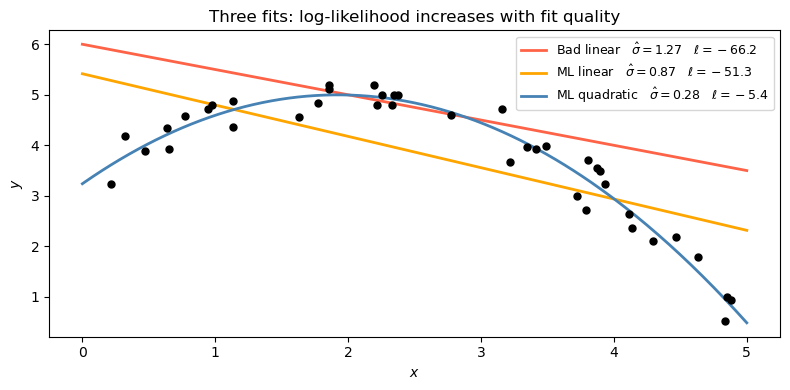

In [4]:
# ── three models ──────────────────────────────────────────────────────────
bad_beta  = np.array([6.0, -0.5])          # hand-picked bad linear fit
ml1_beta  = fit_poly(x_data, y_data, 1)   # ML linear
ml2_beta  = fit_poly(x_data, y_data, 2)   # ML quadratic

fits = [
    ('Bad linear',  bad_beta,  'tomato'),
    ('ML linear',   ml1_beta,  'orange'),
    ('ML quadratic',ml2_beta,  'steelblue'),
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_data, y_data, color='black', s=25, zorder=4)

for label, beta, color in fits:
    y_hat  = predict(x_data, beta)
    sigma_ = ml_sigma(y_data, y_hat)
    ell    = log_likelihood(y_data, y_hat, sigma_)
    ax.plot(x_fine, predict(x_fine, beta), color=color, linewidth=2,
            label=f'{label}   $\\hat{{\\sigma}}={sigma_:.2f}$   $\\ell={ell:.1f}$')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Three fits: log-likelihood increases with fit quality')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The **bad linear** fit has a large RSS and correspondingly low log-likelihood.  The **ML linear** fit is better but misses the curve's bend.  The **ML quadratic** fit captures the curvature, reducing the RSS further and raising the log-likelihood.  Its $\hat\sigma \approx 0.4$ — close to the true noise level.

---
## 3 · Overfitting and model selection

The log-likelihood at the MLE is a function of $\hat\sigma^2 = \mathrm{RSS}/n$:
$$
  \ell(\hat{\boldsymbol{\beta}},\hat\sigma)
  = -\frac{n}{2}\bigl(1 + \log(2\pi\hat\sigma^2)\bigr).
$$
Because $\hat\sigma^2$ decreases monotonically as we add polynomial terms (each new term can only reduce the RSS), the **training log-likelihood rises with every extra parameter**.  We can make it as large as we like by adding complexity — a useless guide for selecting a model.

**Leave-one-out cross-validation (LOO-CV)** penalises complexity automatically: it measures how well a model fit on $n-1$ points predicts the one left out, and averages this over all $n$ leave-outs.

> **Book link — §5.4.** The text shows that the training log-likelihood is maximised by an interpolating polynomial and argues for CV as the remedy.

In [5]:
def loocv_rmse(x, y, degree):
    """LOO-CV root-mean-squared prediction error for a polynomial of given degree."""
    n = len(x)
    sq_errors = []
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        beta_i = fit_poly(x[mask], y[mask], degree)
        y_hat_i = predict(x[i:i+1], beta_i)[0]
        sq_errors.append((y[i] - y_hat_i)**2)
    return np.sqrt(np.mean(sq_errors))

degrees = list(range(10))   # p = 0, 1, ..., 9

train_ll   = []
ml_sigmas  = []
cv_rmses   = []

for p in degrees:
    beta   = fit_poly(x_data, y_data, p)
    y_hat  = predict(x_data, beta)
    sig_ml = ml_sigma(y_data, y_hat)
    train_ll.append(log_likelihood(y_data, y_hat, sig_ml))
    ml_sigmas.append(sig_ml)
    cv_rmses.append(loocv_rmse(x_data, y_data, p))

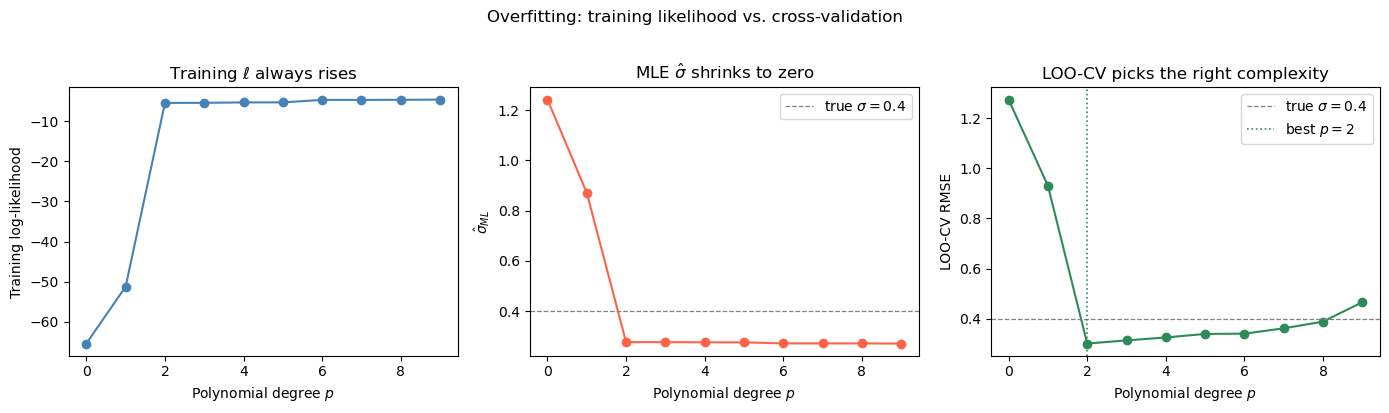

Best degree by LOO-CV: p = 2  (true degree is 2)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(degrees, train_ll, 'o-', color='steelblue')
axes[0].set_xlabel('Polynomial degree $p$')
axes[0].set_ylabel('Training log-likelihood')
axes[0].set_title('Training $\\ell$ always rises')

axes[1].plot(degrees, ml_sigmas, 'o-', color='tomato')
axes[1].axhline(TRUE_SIGMA, color='grey', linestyle='--', linewidth=0.9,
                label=f'true $\\sigma = {TRUE_SIGMA}$')
axes[1].set_xlabel('Polynomial degree $p$')
axes[1].set_ylabel('$\\hat{\\sigma}_{ML}$')
axes[1].set_title('MLE $\\hat{\\sigma}$ shrinks to zero')
axes[1].legend()

axes[2].plot(degrees, cv_rmses, 'o-', color='seagreen')
axes[2].axhline(TRUE_SIGMA, color='grey', linestyle='--', linewidth=0.9,
                label=f'true $\\sigma = {TRUE_SIGMA}$')
best_p = int(np.argmin(cv_rmses))
axes[2].axvline(best_p, color='seagreen', linestyle=':', linewidth=1.2,
                label=f'best $p = {best_p}$')
axes[2].set_xlabel('Polynomial degree $p$')
axes[2].set_ylabel('LOO-CV RMSE')
axes[2].set_title('LOO-CV picks the right complexity')
axes[2].legend()

plt.suptitle('Overfitting: training likelihood vs. cross-validation', y=1.02)
plt.tight_layout()
plt.show()

print(f'Best degree by LOO-CV: p = {best_p}  (true degree is 2)')

**Left panel**: the training log-likelihood rises with every degree added — it will never tell us to stop.

**Middle panel**: $\hat\sigma_{ML}$ falls toward zero as the polynomial interpolates the data, far below the true $\sigma = 0.4$.

**Right panel**: LOO-CV RMSE dips at $p = 2$ (the true degree) and then climbs again as variance overwhelms any further reduction in bias.  Cross-validation recovers the correct complexity.

---
## 4 · Connection to unsupervised learning

Chapter 3 introduced *unsupervised* probabilistic models, where there is no response variable — we model the joint distribution of all the features.  The log-likelihood still plays the central role:
$$
  \ell(\boldsymbol{\theta}) = \sum_{k=1}^n \log p(x_k \mid \boldsymbol{\theta}).
$$
For a **Gaussian mixture** with $K$ components and parameters $\boldsymbol{\theta} = (\pi_j, \mu_j, \Sigma_j)_{j=1}^K$, this is exactly the "log-product score" used in Chapter 3 to select $K$.

> **Book link — §5.5.** The text unifies supervised and unsupervised learning under the common framework of maximising a log-likelihood.

The code below verifies numerically that `GaussianMixture.score` (which returns the per-sample log-likelihood) equals what you get by summing log-densities by hand.

In [7]:
from sklearn.mixture import GaussianMixture

# fit a 2-component Gaussian mixture to a tiny 1-D dataset
z = np.concatenate([rng.normal(-2, 0.5, 30), rng.normal(3, 0.8, 30)])
Z = z.reshape(-1, 1)

gm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
gm.fit(Z)

# sklearn's reported log-likelihood per sample
sklearn_ll_per_sample = gm.score(Z)

# manual calculation: log( sum_j pi_j * N(z; mu_j, sigma_j^2) )
manual_ll = 0.0
for z_i in z:
    density = sum(
        gm.weights_[j] * stats.norm.pdf(z_i, gm.means_[j, 0],
                                         np.sqrt(gm.covariances_[j, 0, 0]))
        for j in range(2)
    )
    manual_ll += np.log(density)

print(f'sklearn  total log-likelihood : {sklearn_ll_per_sample * len(z):.4f}')
print(f'manual   total log-likelihood : {manual_ll:.4f}')
print(f'Match: {np.isclose(sklearn_ll_per_sample * len(z), manual_ll, atol=1e-6)}')

sklearn  total log-likelihood : -92.9345
manual   total log-likelihood : -92.9345
Match: True


The two calculations agree exactly.  The "log-product score" from Chapter 3 and the supervised log-likelihood from Chapter 5 are the same object — a sum of log-densities — evaluated under different model families.

---
## Exercises

### Exercise 1 — Residual diagnostics

A key assumption of the Gaussian noise model is that the residuals $r_k = y_k - \hat{y}_k$ are (a) normally distributed and (b) show no pattern when plotted against the fitted values.

Fit a **linear** ($p=1$) and a **quadratic** ($p=2$) polynomial to the toy dataset.  For each fit, produce two diagnostic plots side by side:

1. **Residuals vs fitted values**: $r_k$ on the $y$-axis, $\hat{y}_k$ on the $x$-axis.  Add a horizontal reference line at zero.
2. **Normal Q-Q plot**: theoretical Gaussian quantiles on the $x$-axis, sorted residuals on the $y$-axis.

Interpret what you see.  Which fit satisfies the model assumptions?

In [8]:
# ── Exercise 1 — your code here ───────────────────────────────────────────


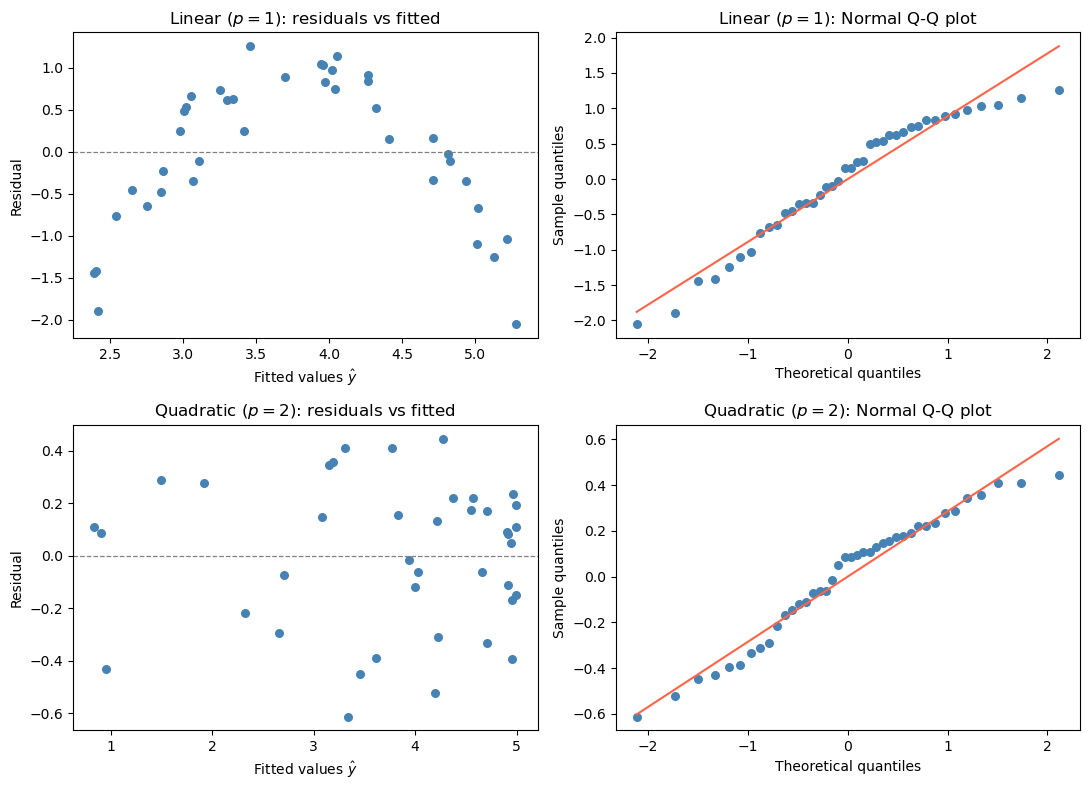

In [9]:
# ── Exercise 1 — solution ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for row, (degree, label) in enumerate([(1, 'Linear ($p=1$)'), (2, 'Quadratic ($p=2$)')]):
    beta  = fit_poly(x_data, y_data, degree)
    y_hat = predict(x_data, beta)
    resid = y_data - y_hat

    # residuals vs fitted
    ax = axes[row, 0]
    ax.scatter(y_hat, resid, color='steelblue', s=30)
    ax.axhline(0, color='grey', linewidth=0.9, linestyle='--')
    ax.set_xlabel('Fitted values $\\hat{y}$')
    ax.set_ylabel('Residual')
    ax.set_title(f'{label}: residuals vs fitted')

    # Q-Q plot using scipy
    ax = axes[row, 1]
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=30)
    x_line = np.array([osm[0], osm[-1]])
    ax.plot(x_line, slope * x_line + intercept, color='tomato', linewidth=1.5)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.set_title(f'{label}: Normal Q-Q plot')

plt.tight_layout()
plt.show()

**Interpretation.**

*Linear fit*: the residuals-vs-fitted plot shows a clear U-shaped pattern — positive residuals at low and high fitted values, negative in the middle.  This is diagnostic of a **systematic curve that the model cannot capture**.  The Q-Q plot may look roughly normal, but the structure in the residuals already tells us the linear model is wrong.

*Quadratic fit*: the residuals scatter randomly around zero with no discernible pattern, and the Q-Q plot lies close to the reference line.  Both checks are consistent with the Gaussian noise assumption — the quadratic fit is adequate.

---
### Exercise 2 — The log-likelihood surface

For the **linear** model $g(x;\boldsymbol{\beta}) = \beta_0 + \beta_1 x$, the noise parameter $\sigma$ can be profiled out (set to its MLE $\hat\sigma(\boldsymbol{\beta}) = \sqrt{\mathrm{RSS}(\boldsymbol{\beta})/n}$).  The resulting **profile log-likelihood**
$$
  \ell_p(\beta_0,\beta_1) = \max_\sigma\, \ell(\beta_0,\beta_1,\sigma)
$$
depends only on $(\beta_0, \beta_1)$.

Show algebraically (one line) that $\ell_p$ is just a decreasing function of $\mathrm{RSS}(\boldsymbol{\beta})$.  Then:

1. Compute $\ell_p$ on a fine grid of $(\beta_0, \beta_1)$ values and draw a filled contour plot.
2. Mark the MLE $\hat{\boldsymbol{\beta}}$ on the plot.
3. Verify numerically that the contours of $\ell_p$ are identical (up to a relabelling of the colour scale) to the contours of $-\mathrm{RSS}$.

In [10]:
# ── Exercise 2 — your code here ───────────────────────────────────────────


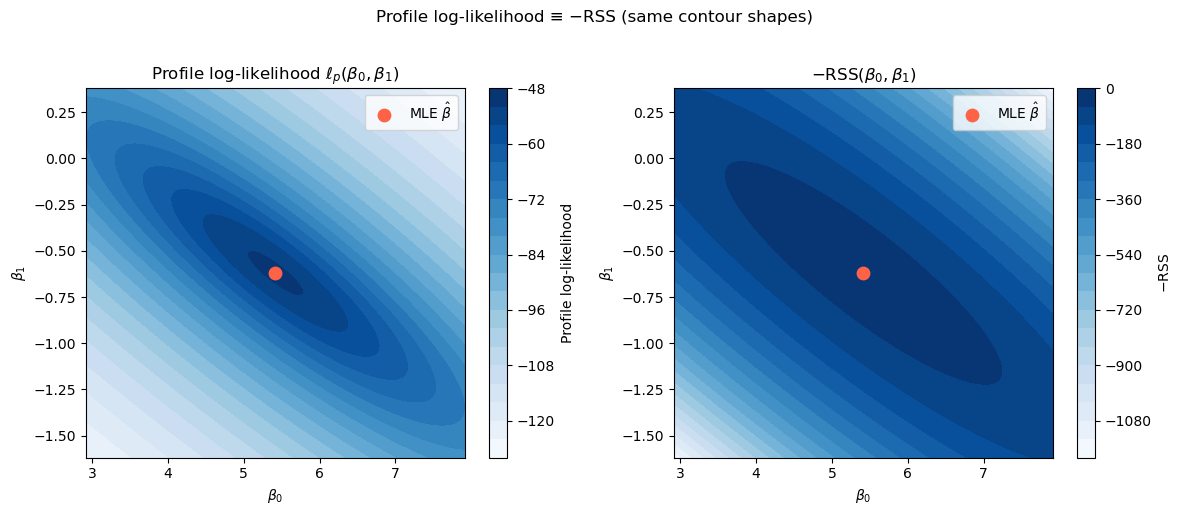

Spearman rank correlation between profile log-likelihood and −RSS: 1.000000
(Expected: 1.000000 — ell_p = −(n/2) log RSS + const is monotone in −RSS)


In [11]:
# ── Exercise 2 — solution ─────────────────────────────────────────────────
#
# Profile log-likelihood:
#   Substituting sigma_hat(beta) = sqrt(RSS/n) gives
#     ell_p = -n/2 * log(2*pi*RSS/n) - n/2
#           = -n/2 * log(RSS) + const.
#   So ell_p is a strictly decreasing function of RSS, confirming the equivalence.

def profile_ll(b0, b1, x, y):
    """Profile log-likelihood for the linear model, sigma profiled out."""
    n = len(y)
    rss_val = np.sum((y - b0 - b1 * x)**2)
    if rss_val <= 0:
        return -np.inf
    sigma_hat = np.sqrt(rss_val / n)
    return -rss_val / (2 * sigma_hat**2) - n * np.log(np.sqrt(2 * np.pi) * sigma_hat)

# MLE for the linear model
b_mle = fit_poly(x_data, y_data, 1)   # [b0_hat, b1_hat]

# grid around the MLE
b0_grid = np.linspace(b_mle[0] - 2.5, b_mle[0] + 2.5, 120)
b1_grid = np.linspace(b_mle[1] - 1.0, b_mle[1] + 1.0, 120)
B0, B1  = np.meshgrid(b0_grid, b1_grid)

PLL = np.array([
    [profile_ll(b0, b1, x_data, y_data) for b0 in b0_grid]
    for b1 in b1_grid
])
RSS_grid = np.array([
    [np.sum((y_data - b0 - b1*x_data)**2) for b0 in b0_grid]
    for b1 in b1_grid
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# profile log-likelihood
cf = axes[0].contourf(B0, B1, PLL, levels=20, cmap='Blues')
fig.colorbar(cf, ax=axes[0], label='Profile log-likelihood')
axes[0].scatter(*b_mle, color='tomato', s=80, zorder=5, label='MLE $\\hat{\\beta}$')
axes[0].set_xlabel('$\\beta_0$')
axes[0].set_ylabel('$\\beta_1$')
axes[0].set_title('Profile log-likelihood $\\ell_p(\\beta_0,\\beta_1)$')
axes[0].legend()

# negative RSS (same contour shapes)
cf2 = axes[1].contourf(B0, B1, -RSS_grid, levels=20, cmap='Blues')
fig.colorbar(cf2, ax=axes[1], label='$-\\mathrm{RSS}$')
axes[1].scatter(*b_mle, color='tomato', s=80, zorder=5, label='MLE $\\hat{\\beta}$')
axes[1].set_xlabel('$\\beta_0$')
axes[1].set_ylabel('$\\beta_1$')
axes[1].set_title('$-\\mathrm{RSS}(\\beta_0,\\beta_1)$')
axes[1].legend()

plt.suptitle('Profile log-likelihood ≡ −RSS (same contour shapes)', y=1.02)
plt.tight_layout()
plt.show()

# numerical check: ell_p = -n/2 * log(RSS) + const, so the rank order of ell_p
# and -RSS must agree perfectly — Spearman rank correlation = 1.
rho, _ = stats.spearmanr(PLL.ravel(), -RSS_grid.ravel())
print(f'Spearman rank correlation between profile log-likelihood and −RSS: {rho:.6f}')
print('(Expected: 1.000000 — ell_p = −(n/2) log RSS + const is monotone in −RSS)')

---
### Exercise 3 — Biased estimation of $\sigma$

The MLE $\hat\sigma^2_{ML} = \mathrm{RSS}/n$ is a **biased** estimator of $\sigma^2$: it systematically underestimates because fitting the polynomial "uses up" $p+1$ degrees of freedom from the data.  The bias-corrected estimator divides by $n - p - 1$ instead:
$$
  s^2 = \frac{\mathrm{RSS}}{n - p - 1}.
$$

Using 500 fresh realisations of the toy dataset (same $x$ values, fresh noise each time), estimate the **expected value** of $\hat\sigma_{ML}$ and $s$ for polynomial degrees $p = 1, \ldots, 8$.  Plot both against the true $\sigma = 0.4$ and comment on the bias of each estimator.

In [12]:
# ── Exercise 3 — your code here ───────────────────────────────────────────


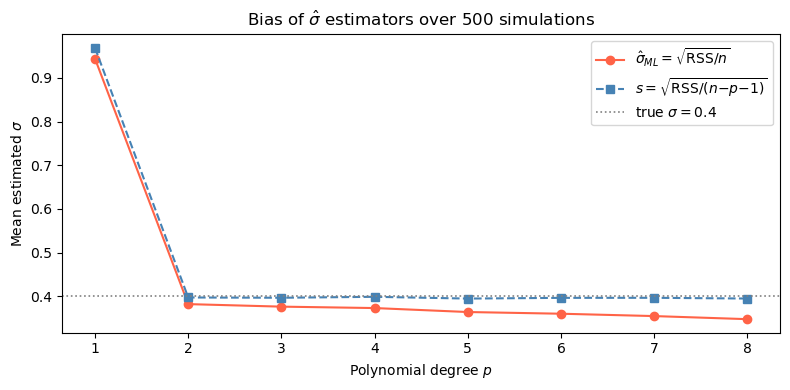

In [13]:
# ── Exercise 3 — solution ─────────────────────────────────────────────────
N_SIM    = 500
sim_rng  = np.random.default_rng(7)
degrees3 = list(range(1, 9))   # p = 1 .. 8

mean_sigma_ml  = []
mean_sigma_bc  = []

for p in degrees3:
    ml_vals, bc_vals = [], []
    for _ in range(N_SIM):
        y_sim    = g_true(x_data) + sim_rng.normal(0, TRUE_SIGMA, size=N)
        beta_sim = fit_poly(x_data, y_sim, p)
        y_hat    = predict(x_data, beta_sim)
        rss_sim  = rss(y_sim, y_hat)
        ml_vals.append(np.sqrt(rss_sim / N))
        df = N - p - 1
        bc_vals.append(np.sqrt(rss_sim / df) if df > 0 else np.nan)
    mean_sigma_ml.append(np.mean(ml_vals))
    mean_sigma_bc.append(np.nanmean(bc_vals))

plt.figure(figsize=(8, 4))
plt.plot(degrees3, mean_sigma_ml, 'o-', color='tomato', label='$\\hat{\\sigma}_{ML} = \\sqrt{\\mathrm{RSS}/n}$')
plt.plot(degrees3, mean_sigma_bc, 's--', color='steelblue', label='$s = \\sqrt{\\mathrm{RSS}/(n{-}p{-}1)}$')
plt.axhline(TRUE_SIGMA, color='grey', linewidth=1.2, linestyle=':', label=f'true $\\sigma = {TRUE_SIGMA}$')
plt.xlabel('Polynomial degree $p$')
plt.ylabel('Mean estimated $\\sigma$')
plt.title(f'Bias of $\\hat{{\\sigma}}$ estimators over {N_SIM} simulations')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation.**

The MLE $\hat\sigma_{ML}$ lies systematically **below** the true $\sigma = 0.4$ at every degree, and the gap widens as $p$ increases — because a higher-degree polynomial absorbs more of the noise into its fit, leaving less in the residuals.

The bias-corrected $s$ tracks the true $\sigma$ much more closely across all degrees.  At very high degrees (close to $n$) even $s$ struggles, because there are very few degrees of freedom left and the division by $n - p - 1$ becomes unstable.

In practice, software (including `numpy.linalg.lstsq` and `statsmodels`) reports $s$, not $\hat\sigma_{ML}$, for exactly this reason.